# ARGUS-FEDER — Answering GA's disruption competency questions

GA's competency-question set (27 questions) splits into an ELM half and a
disruption half. This notebook works through the **disruption half, Q14–Q27**,
against the stored disruption index built from `disruption-py` output.

Two things to keep in mind throughout: GA's questions are written for **three**
disruption pipelines and we have run **one**; and the index holds **20 shots,
balanced 10 disrupted / 10 not**, so it is a demonstration slice rather than a
sample of the archive. Several questions below are answered correctly by
declining to answer.

Every question below is typed in plain English into a `%%ask` cell. The agent
decides what to look up, writes and runs its own code, and reports back.
**Nothing here requires you to write code.**

Questions are marked `--review`: before an answer reaches you, a grader
sub-agent checks it against a stated rubric and sends it back for revision if
it fails. Watch for the verdict panel under each answer.

#### Step 1 — Prepare your session (one-time)

Run the cell below. **Your session will restart automatically — that is
expected.** Once it comes back, carry on with Step 2.

In [1]:
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/25.11.0-1/Miniforge3-25.11.0-1-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:11
🔁 Restarting kernel...


#### Step 2 — Choose your AI model

Pick one and run the cell (defaults to a free NRP model).

In [1]:
# Use GLM-5 from National Research Platform
LLM = {
    "model": "deepseek-v4-flash",
    "url": "https://ellm.nrp-nautilus.io/v1",
    "api_key_env": "NRP_API_KEY",
}

# Use GPT-5.5 from OpenAI
# LLM = {
#     "model": "gpt-5.5",
#     "api_key_env": "OPENAI_API_KEY",
# }

# Use Claude Sonnet 4.6 from Anthropic
# LLM = {
#     "model": "claude-sonnet-4-6",
#     "api_key_env": "ANTHROPIC_API_KEY",
#     "flavor": "anthropic",
# }

# Use Gemini 3.5 Flash from Google
# LLM = {
#     "model": "gemini-3.5-flash",
#     "api_key_env": "GOOGLE_API_KEY",
#     "flavor": "gemini",
# }

# Use GLM-5 from ZAI
# LLM = {
#     "model": "glm-5",
#     "url": "https://api.z.ai/api/coding/paas/v4",
#     "api_key_env": "ZAI_API_KEY",
# }

#### Step 3 — Add your keys

Click the key icon in the left sidebar and add your secrets (toggle
"Notebook access" on for each):

- The API key matching what you picked in Step 2 (e.g. `NRP_API_KEY`)
- **Optional:** your DIII-D Pelican access token, named `FDP_TOKEN`. Every
  question in this notebook is answered from the stored index and needs no
  raw-signal access.

#### Step 4 — Install ARGUS-FEDER

In [2]:
import urllib.request
exec(urllib.request.urlopen(
    'https://raw.githubusercontent.com/klinucsd/argus_feder/main/install.py'
).read().decode(), globals())

Setting up ARGUS-FEDER...
  • Installing DIII-D data access (~1-2 min, one-time)
    ............
    ....
  • DIII-D data access ready
  • Pelican token loaded
  • Review rubric extended (+3 criteria; use %%ask --review)
  • Installing the ARGUS agent (~1 min the first time)
ARGUS bootstrap starting...
  ✓ Wrote LLM config to /root/.deepagents/config.toml (added default params for 1 ChatOpenAI provider(s))
  ✓ Loaded NRP_API_KEY from Colab Secrets
  · Installing ARGUS dependencies (~30–90 s the first time)...
  ✓ ARGUS dependencies installed
  ✓ Downloaded sage_magic.py + sage_kernel_backend.py from main
  ✓ Installed 16 core skill(s) into /root/.deepagents/agent/skills: arcgis-feature-skill-builder, array-skill-builder, ckan-skill-builder, local-skill-builder, ndp-search, ndp-skill-builder, repo-skill-builder, s3-skill-builder, sage-bbox-map, sage-dropdown, sage-metrics, skillsmp, tabular-skill-builder, us-counties, us-states, zenodo-skill-builder

ARGUS ready — %%ask, %%mcp, %%skill

In [ ]:
%reset

#### Step 5 — Upload the disruption index

The questions read from one SQLite file, which is not bundled with the
installer. Open the **file browser** (folder icon, left sidebar) and drag it
in; it lands in `/content/`, where the skill looks automatically.

| file | size | needed for |
|---|---|---|
| `disruption.sqlite` | ~2 MB | every question |

The upload takes seconds, but **must be repeated for each fresh Colab
session** — Colab discards local files when the runtime is recycled.

Do not mount Google Drive for this: uploading one small file per session is
faster than the mount flow and does not hand the notebook access to your whole
Drive.

#### Step 6 — Confirm the index was found

Plain Python, no agent. Prints the file it located, its provenance, and the
coverage every answer below is conditional on.

In [3]:
import os, sys
sys.path.insert(0, os.path.expanduser("~/.deepagents/agent/skills/d3d-disruption"))
from d3d_disruption import index_info, locate_disruption_db

print("database:", locate_disruption_db())
i = index_info()
print(f"{i['n_shots']} shots ({i['n_disrupted']} disrupted), {i['n_sample_rows']:,} sample rows")
print(f"produced by {i['package']} {i['version']} @ {i['commit_sha'][:8]} on {i['produced_at'][:10]}")
print()
print(i['coverage_note'])

database: /content/disruption.sqlite
20 shots (10 disrupted), 3,778 sample rows
produced by disruption_py 0.15.0.dev0 @ 9987784e on 2026-08-19

20 shots, 10 disrupted. This is a constructed slice, not a random sample of DIII-D. Rates and fractions computed from it describe the slice only.


## Q20 — Which pipeline produced a label, at what version, from which inputs?

*provenance · **answerable***

Our assessment predicted this would become "✅ by construction" once we ran a
pipeline ourselves and recorded what we ran.

In [4]:
%%ask --review
For the disruption labels in the index: which code produced them, at what
version and commit, when was it run and by whom, and what were its inputs? Show
me the full provenance record.

I'll consult the d3d-disruption skill since this is a provenance question about the disruption index.



The skill documents `index_info()` for provenance. Let me read the helper module to see its exact return shape.



Let me check the `ingest_runs` table schema to know what provenance fields exist.



Now I'll write a script that calls `index_info()` and dumps the full `ingest_runs` provenance record.



Running the provenance script.



...

Let me pull the shot list to describe the run's inputs fully.



The rows printed as sqlite3.Row objects — let me fix the script to convert them to dicts.



I have the full provenance record. Let me also pull the parameter dictionary to describe the run's inputs (the 65 variables).



Let me back the two flagged figures with actual tool calls — first `unusable_parameters()` and `label_disagreements()`.



Both figures are now backed by tool output. Here is the complete report.

## Provenance of the disruption labels in the index

The disruption labels in this index were produced by **disruption-py** (the MIT-PSFC disruption prediction package), and the full provenance record is stored in the index's `ingest_runs` table, sourced from the NetCDF global attributes of the input file. Here is the complete record:

### Producing code

| Field | Value |
|---|---|
| **Package** | `disruption_py` |
| **Version** | `0.15.0.dev0` |
| **Commit** | `9987784e78ef9736e2fe42142683b3458ff38d8d` |
| **Source** | https://github.com/MIT-PSFC/disruption-py/tree/9987784e78ef9736e2fe42142683b3458ff38d8d |
| **Tokamak** | D3D |

The parameters and their known defects (e.g. `time_domain`, `ip_error`, `dipprog_dt`) are properties of this exact revision — `0.15.0.dev0` at commit `9987784e`.

### When it was run and by whom

| Field | Value |
|---|---|
| **Produced by** | `sammuli` |
| **Produced on** | `omega06.gat.com` (a GAT computing host) |
| **Produced at** | `2026-08-19T07:36:50.648611` |

### Inputs

| Field | Value |
|---|---|
| **Source file** | `d3d_disruption_example.nc` (the NetCDF written by disruption-py) |
| **Shots ingested** | 20 (shot range 194000–199687) |
| **Sample rows** | 3,778 |
| **Parameters** | 63 total — 60 usable, 3 flagged unusable |
| **Disrupted / not** | 10 / 10 |

The 63 parameters were computed by disruption-py's physics methods across 14 groups — equilibrium reconstruction (`get_efit_parameters`, 14 params), real-time EFIT (5), plasma current (`get_ip_parameters`, 5) and its real-time variant (5), density (3 + 3 real-time), power (4), ohmic (2), shape (4), n=1 mode (4), peaking factors (4), plus scalars like `btor`, `h98`, `h_alpha`, `z_eff`, `power_supply_railed`, and the three label/phase columns (`time_until_disrupt`, `current_quench_time`, `time_domain`).

The 3 unusable parameters, per `unusable_parameters()`:

| Parameter | Defect |
|---|---|
| `time_domain` | Constant 1.0 for every row — flat-top detection tests `\|ip_prog\| >= 100e3` but `ip_prog` is in MA (order 1), so the test never fires |
| `ip_error` | Numerically identical to `ip` (median \|ip_error − ip\| = 1.7 A vs median \|ip\| of 788 kA, 2.1e-6 relative) — `ip_prog` is in MA but used unscaled, so the subtraction is a no-op |
| `dipprog_dt` | In MA/s while its real-time twin `dipprog_dt_rt` is in A/s, differing by ~5e5 — use `dipprog_dt_rt` |

### Ingestion into this index

| Field | Value |
|---|---|
| **Ingested at** | `2026-08-19T20:46:49+00:00` |
| **Run ID** | 1 |

### Notes on the labels

- The **authoritative disruption label** is `time_until_disrupt`, taken from the human-curated `disruptions` table in d3drdb — not from disruption-py's own `current_quench_time` estimate. Per `label_disagreements()`, the two disagree on **3 of the 20 shots — 198244, 198643, 199062** — in each case the curated label says not-disrupted while the derived estimate says disrupted.
- The 20-shot slice is a **constructed, balanced sample** (10 disrupted / 10 not), not a random sample of DIII-D — so no rate or fraction computed from it describes DIII-D as a whole.

**Coverage note** (from `index_info()`): 20 shots, 10 disrupted. This is a constructed slice, not a random sample of DIII-D. Rates and fractions computed from it describe the slice only.

## Q15 — Which quantities are disruption precursors, and what measures each?

*precursor map · **answerable***

The assessment noted that `disruption-py`'s feature set *is* the precursor
map — n=1 mode amplitude, betap, li, q95, radiated fraction, locked mode,
v_loop. Now that it has been run, that map is queryable with units attached.

In [5]:
%%ask --review
Which quantities in this dataset are disruption precursors, and what does
each one measure? Group them by the physics method that produces them, and give
the units for each.

Reading the d3d-disruption skill to see how to query the index and its parameter metadata.



The skill's parameter dictionary is exactly what this question needs. Let me check the helper module's API surface before writing the query script.



Let me read the rest of the module to see the remaining functions.



The parameter dictionary is exactly what this question needs. Let me write a script that pulls all parameters, groups them by producing physics method, and reports units and meaning for each.



Running the script to enumerate all parameters grouped by physics method.



The parameter dictionary gives me everything needed. Here is the complete breakdown.

## Disruption precursors in this index

The index holds **63 parameters** ; **60 are physics quantities** that disruption-py computes as disruption-warning inputs (the precursors), and **3 are labels/phase columns that are not precursors** (`time_until_disrupt`, `current_quench_time`, `time_domain`). Of the 60 physics parameters, **3 are flagged unusable** (they return plausible but wrong values) and are marked below. Units follow the index convention: `1` = dimensionless, `instrument` = uncalibrated instrument units, `0/1` = boolean flag.

**Coverage note** (from `index_info()`): 20 shots, 10 disrupted. This is a constructed slice, not a random sample of DIII-D. Rates and fractions computed from it describe the slice only.

### Equilibrium reconstruction — `get_efit_parameters` (14)

| Parameter | Measures | Units |
|---|---|---|
| `wmhd` | Stored magnetic energy | J |
| `dwmhd_dt` | d(wmhd)/dt | W |
| `beta_n` | Normalised beta | % m T MA⁻¹ |
| `beta_p` | Poloidal beta | 1 |
| `dbetap_dt` | d(beta_p)/dt | s⁻¹ |
| `q95` | Safety factor at 95% flux surface | 1 |
| `q0` | Safety factor on axis | 1 |
| `qstar` | Cylindrical safety factor | 1 |
| `li` | Internal inductance | 1 |
| `dli_dt` | d(li)/dt | s⁻¹ |
| `kappa` | Elongation | 1 |
| `lower_gap` | Gap, plasma to lower wall | m |
| `upper_gap` | Gap, plasma to upper wall | m |
| `chisq` | EFIT fit quality | 1 |

### Plasma current — `get_ip_parameters` (5)

| Parameter | Measures | Units |
|---|---|---|
| `ip` | Measured plasma current | A |
| `ip_prog` | Programmed plasma current | MA |
| `dip_dt` | d(ip)/dt | A s⁻¹ |
| `dipprog_dt` | d(ip_prog)/dt — **UNUSABLE** (MA/s vs A/s twin, off by ~5e5; use `dipprog_dt_rt`) | MA s⁻¹ |
| `ip_error` | ip − ip_prog — **UNUSABLE** (numerically identical to ip; unit mismatch) | A |

### MHD modes — `get_n1_bradial_parameters` / `get_n1rms_parameters` (4)

| Parameter | Measures | Units |
|---|---|---|
| `n1rms` | n=1 RMS amplitude | T |
| `n1rms_normalized` | n=1 RMS normalised by toroidal field | 1 |
| `n_equal_1_mode` | n=1 radial field amplitude | T |
| `n_equal_1_normalized` | n=1 amplitude normalised by toroidal field | 1 |

### Heating and radiation — `get_power_parameters` (4)

| Parameter | Measures | Units |
|---|---|---|
| `p_rad` | Radiated power (bolometry, causal 10 ms smoothing) | W |
| `p_nbi` | Neutral-beam injected power | W |
| `p_ech` | Electron-cyclotron heating power | W |
| `radiated_fraction` | p_rad / total input power (needs clipping) | 1 |

### Line-averaged density — `get_density_parameters` (3)

| Parameter | Measures | Units |
|---|---|---|
| `n_e` | Line-averaged electron density | m⁻³ |
| `dn_dt` | d(n_e)/dt | m⁻³ s⁻¹ |
| `greenwald_fraction` | n_e / Greenwald density limit | 1 |

### Ohmic drive — `get_ohmic_parameters` (2)

| Parameter | Measures | Units |
|---|---|---|
| `v_loop` | Loop voltage | V |
| `p_ohm` | Ohmic heating power | W |

### Geometry — `get_shape_parameters` / `get_kappa_area` (4)

| Parameter | Measures | Units |
|---|---|---|
| `aminor` | Minor radius | m |
| `delta` | Triangularity (mean of top and bottom) | 1 |
| `kappa_area` | Elongation from cross-sectional area | 1 |
| `squareness` | Squareness | 1 |

### Vertical position — `get_z_parameters` (2)

| Parameter | Measures | Units |
|---|---|---|
| `zcur` | Vertical position of the current centroid | m |
| `zcur_normalized` | zcur normalised by minor radius | 1 |

### Profile peaking (real-time) — `get_peaking_factors` (4)

| Parameter | Measures | Units |
|---|---|---|
| `ne_peaking_cva_rt` | Electron density peaking, core vs. all | 1 |
| `te_peaking_cva_rt` | Electron temperature peaking, core vs. all | 1 |
| `prad_peaking_cva_rt` | Radiated power peaking, core vs. all | 1 |
| `prad_peaking_xdiv_rt` | Radiated power peaking, divertor region | 1 |

### Real-time equilibrium — `get_rt_efit_parameters` (5)

| Parameter | Measures | Units |
|---|---|---|
| `wmhd_rt` | Stored energy (real-time) | J |
| `q95_rt` | q95 (real-time) | 1 |
| `beta_p_rt` | Poloidal beta (real-time) | 1 |
| `li_rt` | Internal inductance (real-time) | 1 |
| `chisq_rt` | Fit quality (real-time) | 1 |

### Real-time plasma current — `get_rt_ip_parameters` (5)

| Parameter | Measures | Units |
|---|---|---|
| `ip_rt` | Measured plasma current (real-time) | A |
| `ip_prog_rt` | Programmed current (real-time) | A |
| `dip_dt_rt` | d(ip)/dt (real-time) | A s⁻¹ |
| `dipprog_dt_rt` | d(ip_prog)/dt (real-time) | A s⁻¹ |
| `ip_error_rt` | Current error (real-time) | A |

### Real-time density — `get_rt_density_parameters` (3)

| Parameter | Measures | Units |
|---|---|---|
| `n_e_rt` | Electron density (real-time) | m⁻³ |
| `dn_dt_rt` | d(n_e)/dt (real-time) | m⁻³ s⁻¹ |
| `greenwald_fraction_rt` | Greenwald fraction (real-time) | 1 |

### Scalar / single-value parameters — `get_btor` / `get_h_alpha` / `get_h98` / `get_zeff_parameters` / `get_power_supply_railed` (5)

| Parameter | Measures | Units |
|---|---|---|
| `btor` | Toroidal magnetic field | T |
| `h98` | H98(y,2) confinement quality factor | 1 |
| `z_eff` | Effective ion charge | 1 |
| `h_alpha` | H-alpha line emission (uncalibrated) | instrument |
| `power_supply_railed` | E-coil supplies at their limit (Ip feedback lost) | 0 / 1 |

### Not precursors — labels and shot phase (3)

| Parameter | Measures | Units |
|---|---|---|
| `time_until_disrupt` | Seconds remaining until disruption; NaN if the shot did not disrupt (the authoritative label) | s |
| `current_quench_time` | Ip-decay-derived quench time (disruption-py's own estimate; disagrees with the label on 3 shots) | s |
| `time_domain` | Shot phase: 1 ramp-up, 2 flat-top, 3 ramp-down — **UNUSABLE** (constant 1.0; flat-top test never fires) | category |

### Summary

- **60 physics parameters** are the disruption precursors, produced by **14 physics methods** (equilibrium reconstruction, plasma current, MHD modes, heating/radiation, density, ohmic, geometry, vertical position, profile peaking, and their real-time variants).
- **3 of the 60 are unusable** — `dipprog_dt`, `ip_error`, `time_domain` — all traced to the same upstream `ip_prog` unit bug (MA used unscaled where A was expected). Use their real-time twins (`dipprog_dt_rt`, `ip_error_rt`) instead; `time_domain` has no usable replacement.
- **3 columns are labels, not precursors** — `time_until_disrupt` (authoritative), `current_quench_time` (derived), `time_domain` (phase).

These parameters and their defects are properties of disruption-py **0.15.0.dev0** at commit **9987784e** (see the provenance record from the previous question).

## Q19 — For a given shot, what is the label and the time, and do the indicators agree?

*label agreement · **partially answerable***

GA asks whether three pipelines agree. We have one — but that one carries **two
independent disruption indicators**, and they disagree on some shots.

In [6]:
%%ask --review
For DIII-D shot 194128, give me the disruption label and the disruption
time. Then tell me whether the dataset contains more than one disruption
indicator, whether they agree, and on which shots they disagree.

I'll consult the d3d-disruption skill to query the index correctly.



The skill documents the exact functions. Let me run them against the live index to verify the values.



Running the query script against the index.



The query ran cleanly against the live index. Here is the report.

## DIII-D shot 194128 — disruption label and time

**Shot 194128 disrupted.** The disruption time is **t = 5.6267 s** .

| Field | Value |
|---|---|
| **Shot** | 194128 |
| **Disrupted** | Yes |
| **Disruption time** | 5.6267 s |
| **Label source** | `time_until_disrupt`, from the human-curated d3drdb disruptions table |
| **Samples in index** | 269 rows, t = 0.10 s → 5.6267 s (the last sample is at the disruption) |

## More than one disruption indicator? Yes — two, and they disagree on 3 shots

The index carries **two disruption indicators** :

1. **`time_until_disrupt`** — the **authoritative label** , taken from the human-curated `disruptions` table in d3drdb. Seconds remaining until disruption; NaN for shots that did not disrupt.
2. **`current_quench_time`** — disruption-py's **own derived estimate** , computed from the Ip decay (the quench time). This is the same quantity the `derived=True` flag returns.

**They do not fully agree.** The two indicators disagree on **3 of the 20 shots** — in every case the curated label says **not disrupted** while the derived estimate says **disrupted** :

| Shot | Curated label (`time_until_disrupt`) | Derived estimate (`current_quench_time`) |
|---|---|---|
| 198244 | Not disrupted | Disrupted (t = 5.2172 s) |
| 198643 | Not disrupted | Disrupted (t = 5.0618 s) |
| 199062 | Not disrupted | Disrupted (t = 6.4290 s) |

**Why this matters:** the derived estimate would shift the class balance from 10/20 to 13/20. The index therefore treats `time_until_disrupt` as the label and requires `derived=True` to see the derived one, so the balance cannot shift silently. The 3 disagreeing shots are exactly the ones flagged by `label_disagreements()`.

**Coverage note** (from `index_info()`): 20 shots, 10 disrupted. This is a constructed slice, not a random sample of DIII-D. Rates and fractions computed from it describe the slice only.

---
# B. Answerable for one pipeline only

## Q14 — What definition of "disruption" does the pipeline implement?

*definition · **one of three pipelines***

In [7]:
%%ask --review
What definition of a disruption, and of the disruption time, does the
pipeline behind these labels use? Where is that definition documented, and how
would I check it? Be clear about which pipeline this is and which ones are
missing.

I'll read the skill documentation to see what's documented about the disruption definition and how to check it.



This question is about the definition behind the labels, which the skill attributes to the d3drdb disruptions table. Let me read the relational-db skill to see how that table and its disruption definition are documented.



Let me look at the helper module to see what documentation the index itself carries about the disruption definition.



This question asks about the *definition* behind the labels, which the skill docs attribute to two different pipelines. Let me check what's actually documented in the skill directory and the index itself.



This is a question about the *definition* behind the labels, which the docs attribute to the curated d3drdb disruptions table. Let me verify what the index and the local d3drdb copy actually document. First, I'll check the relational-db helper's interface.



...

This confirms the chain. Let me also verify the `end_of_current` routine referenced in `test_for_disruption.m` to complete the definition of shot duration, and check the `disruption_warning_database_d3d.m` header for the RSG attribution.



I now have the complete, authoritative definition chain. Let me verify the header attribution of the MATLAB routine and confirm the `disruption_warning_database_d3d.m` header (RSG = Robert S. Granetz).





I now have the complete, authoritative picture. Let me verify the exact disruption time for shot 194128 from the index to cross-check the definition, and confirm the `t_disrupt` value matches the criterion (the time of max |dI/dt| during the quench).



I now have everything needed. Let me clean up the intermediate files I created during this investigation.



## The disruption definition behind these labels

### Which pipeline this is

There are **two distinct pipelines** in play, and only one of them defines the labels:

1. **The label pipeline (this is the one that matters)** — the disruption labels in this index come from the **`disruptions` table in the DIII-D shot database (d3drdb)** , populated by **Robert Granetz's MATLAB routine** `test_for_disruption.m`. This is the authoritative source. The index's `time_until_disrupt` column is literally `t_disrupt − t` for each sample, where `t_disrupt` is read from that table.

2. **The derived pipeline (a different definition)** — disruption-py's own `current_quench_time`, computed from the Ip decay. This is *not* the label; it disagrees with the curated label on 3 shots (198244, 198643, 199062).

### The definition of a disruption (Granetz's routine)

`test_for_disruption.m` declares a shot **disrupted** if and only if **all six** criteria hold (parameters tuned for DIII-D):

| # | Criterion | Value |
|---|---|---|
| 1 | Shot duration > 0.5 s (reject very short shots) | `duration_min = 0.5 s` |
| 2 | \|Ip_max\| > 0.1 MA (reject very low current shots) | `Ip_threshold = 0.1e6 A` |
| 3 | Ip0 / Ip_max > 0.33 (reject shots that disrupt late in current rampdown) | `0.33` |
| 4 | Ip0 / max\|dI/dt\| < 0.050 s (reject slow current decay) | `tau_CQ_max = 0.050 s` |
| 5 | \|Ip_final\| < 100 kA within 0.15 s of t_disrupt (reject minor disruptions) | `Ip_final_max = 100e3 A` |
| 6 | \|Ip0\| > 0.1 MA (reject very low current disruptions) | `Ip_threshold = 0.1e6 A` |

where:
- **Ip0** = mean plasma current over the window `[duration − 0.06, duration − 0.04]` s (the pre-disruption current);
- **duration** = shot termination time from `end_of_current.m`, the last time \|Ip\| ≥ 100 kA (with a 0.1 s minimum-plasma floor);
- **max\|dI/dt\|** = the most negative dI/dt in the window `[duration − 0.05, duration + 0.05]` s.

### The definition of the disruption time

**`t_disrupt` = the time of maximum |dI/dt| during the current quench** — specifically, the time index of the most negative dI/dt in the window `[duration − 0.05, duration + 0.05]` s. The routine's own words: *"the time of maximum abs(dI/dt) is the disruption time."*

This is consistent with the index: shot 194128 has `t_disrupt = 5.6267 s`, and the last sample (t = 5.6267 s, `time_until_disrupt = 0`) is exactly at the disruption.

### Where this is documented, and how to check it

The definition is documented in **three places** , each one level deeper:

1. **The disruption-py docstring** — `get_time_until_disrupt` in `disruption_py/machine/d3d/physics.py` says: *"the disruption time is queried from the `DISRUPTIONS` table in the SQL database of each machine. These disruption times were calculated using Robert Granetz's routine."* (references issue #223).

2. **The MATLAB source** — `DIII-D/analysis/test_for_disruption.m` in the `matlab` branch of the disruption-py repo contains the full six-criterion definition quoted above, with the header *"partially based on those used by Robert Granetz and Steve Wolfe for Alcator C-Mod. The parameters have been adjusted for the D3D tokamak."* (author RSG, created 2015/01/26).

3. **The consuming routine** — `DIII-D/disruption_warning_database_d3d.m` (also RSG) reads `select shot, t_disrupt from disruptions` and computes `time_until_disrupt = t_disrupt − times_for_db`, which is exactly what the index stores.

**How you would check it:** the disruption-py repo is public at `github.com/MIT-PSFC/disruption-py`. The Python docstring is in `disruption_py/machine/d3d/physics.py` (main branch); the authoritative MATLAB definition is in the `matlab` branch at `DIII-D/analysis/test_for_disruption.m`. The `disruptions` table itself lives in the DIII-D shot database (d3drdb) at GA — it is **not** in the local trimmed copy, which deliberately excludes the legacy `DISRUPTIONS`/`disruption_warning` tables.

### What is missing

- **The pinned commit is not in the public repo.** The index's provenance records disruption-py `0.15.0.dev0` at commit `9987784e` — a dev build produced on a GAT host (`omega06.gat.com`). GitHub returns *"No commit found for SHA: 9987784e"* for that commit, so the exact source revision that produced this index is **not publicly retrievable** . I verified the definition against the current `main` and `matlab` branches instead; the six-criterion routine is stable and matches the index's behavior.
- **The `disruptions` table contents are not locally available** — only the label values that were copied into this index. The full table (all DIII-D shots, not just the 20-shot slice) lives at GA.
- **The index itself stores no definition text** — its parameter dictionary documents only the *meaning* of `time_until_disrupt` ("Seconds remaining until disruption; NaN if the shot did not disrupt"), not the criterion that produced `t_disrupt`. The definition lives upstream in the MATLAB routine, not in the index.

**Coverage note** (from `index_info()`): 20 shots, 10 disrupted. This is a constructed slice, not a random sample of DIII-D. Rates and fractions computed from it describe the slice only.

## Q22 — Which shots have every input the pipeline requires?

*input availability · **partially answerable***

Let me consult the d3d-disruption skill to see the exact query interface for completeness analysis.



The skill exposes `parameter_info()` with a `fill_pct` field — exactly what I need. Let me check the helper module for the schema and any per-shot completeness helpers.



The skill's `parameter_info()` exposes `fill_pct` per parameter, and the module's `_query` seam lets me compute per-shot completeness. Let me write a script that analyzes fill across all parameters and drills into which shots are affected.



Running the completeness analysis against the live index.



The samples table is wide (one column per parameter), not long. Let me inspect the actual schema.



The table is wide — one column per parameter. Rewriting the analysis to count non-NULL per column, both overall and per shot.



The analysis is complete. Let me verify one pattern — whether the EFIT-group gaps sit at the edges of each shot (pre-convergence / post-disruption) rather than being random.



The edge-check confirms the EFIT-group gaps sit at shot edges (pre-convergence and post-disruption). Let me generate a fill-percentage bar chart to accompany the report.



The grader is right on both counts. Let me re-verify the exact numbers from the tool output before rewriting.

From the run: `current_quench_time` is missing in **7** shots — 194005, 194869, 195243, 195805, 196273, 199359, 199687 (the 10 non-disrupted minus the 3 disagreement shots 198244/198643/199062, which *do* carry a derived quench time). And the sparse list below 90% contains **27** parameters: 2 labels + **20** EFIT-derived (14 `get_efit_parameters` + `p_ohm`, `radiated_fraction`, `aminor`, `delta`, `kappa_area`, `zcur_normalized`) + 4 whole-shot + 1 `h98`. The "17" was a miscount. Here is the corrected, self-consistent report.

## Parameter completeness across the index

The pipeline produces **63 parameters** (60 physics quantities + 3 label/phase columns). Across the **3,778 sample rows** of the 20-shot index, fill is **not uniform** — 27 of 63 parameters fall below 90% populated. The gaps fall into four distinct patterns, each with a different cause.

### Pattern 1 — Labels that are NaN by design (2 parameters)

These are **not data gaps** ; the NaN is the correct value.

| Parameter | Fill | Why |
|---|---|---|
| `time_until_disrupt` | 48.8% | NaN for all rows of the 10 **non-disrupted** shots — there is no disruption time to count down to |
| `current_quench_time` | 66.4% | NaN for all rows of the **7 non-disrupted shots that lack a derived estimate** (194005, 194869, 195243, 195805, 196273, 199359, 199687) |

`time_until_disrupt` is missing in exactly the 10 non-disrupted shots (194005, 194869, 195243, 195805, 196273, 198244, 198643, 199062, 199359, 199687). `current_quench_time` is missing in **7** shots — the 10 non-disrupted **minus** the 3 disagreement shots (198244, 198643, 199062), which **do** carry a derived quench time. That is precisely why they are flagged as disagreements: the curated label says not-disrupted while the derived estimate says disrupted. The other 13 shots (all 10 disrupted + those 3) have `current_quench_time` populated for every row.

### Pattern 2 — EFIT-derived quantities, missing at shot edges (20 parameters)

A block of **20 parameters** — the entire `get_efit_parameters` group (14: `wmhd`, `beta_n`, `beta_p`, `q95`, `q0`, `qstar`, `li`, `kappa`, `chisq`, `lower_gap`, `upper_gap`, `dwmhd_dt`, `dbetap_dt`, `dli_dt`), plus `p_ohm`, `radiated_fraction`, `aminor`, `delta`, `kappa_area`, `zcur_normalized` — all sit at **84.6%** (or 82.5% for the three time-derivatives). The missing rows are **not random** : they are the first ~0.1–0.5 s of each shot (before EFIT converges) and the final samples after the disruption (when the equilibrium fit is lost). Verified on shot 194128: `beta_n` is filled only from t = 0.200 s to t = 5.619 s, missing the first 0.1 s and the last 0.008 s; on shot 195805 the missing block is the final 0.4 s (t = 6.525–6.925 s). Shot 194464 is the extreme case — only 10 of 171 rows have EFIT values (t = 0.5–1.45 s), because it disrupts very early (t_disrupt = 3.18 s) and the fit never stabilises.

**Every one of the 20 shots** has some rows missing these parameters, but the *fraction* missing per shot is small (typically 5–20% of that shot's rows) — it is edge loss, not whole-shot loss.

### Pattern 3 — Whole-shot absence (4 parameters)

These are missing for **entire shots** , not just edges:

| Parameter | Fill | Missing shots (0% filled) |
|---|---|---|
| `z_eff` | 51.2% | 194000, 194005, 194128, 194292, 194464, 194649, 194968, 195805, 196273, 198244 (10 shots) |
| `squareness` | 70.9% | 194000, 194005, 194128, 194292, 194464, 195516 (6 shots) |
| `ne_peaking_cva_rt` | 73.2% | 194000, 195805, 196273, 198244 (4 shots) |
| `te_peaking_cva_rt` | 73.2% | 194000, 195805, 196273, 198244 (4 shots) |

`z_eff` is the worst: **half the shots have no `z_eff` at all** , including shot 194128 (the flagship disrupted shot from earlier). `squareness` is absent for 6 shots. The two peaking factors are absent for the same 4 shots (194000, 195805, 196273, 198244) — a shared upstream cause (no Thomson profile data for those shots).

### Pattern 4 — Sparse but present everywhere (1 parameter)

| Parameter | Fill | Notes |
|---|---|---|
| `h98` | 73.7% | Missing in all 20 shots to some degree; **completely absent** in 4 shots (194649, 194869, 195985, 198643) |

### Summary of the affected shots

| Parameter | Fill | Affected shots |
|---|---|---|
| `time_until_disrupt` | 48.8% | 10 non-disrupted shots (by design) |
| `z_eff` | 51.2% | 10 shots entirely: 194000, 194005, 194128, 194292, 194464, 194649, 194968, 195805, 196273, 198244 |
| `current_quench_time` | 66.4% | 7 shots entirely (by design): 194005, 194869, 195243, 195805, 196273, 199359, 199687 |
| `squareness` | 70.9% | 6 shots entirely: 194000, 194005, 194128, 194292, 194464, 195516 |
| `h98` | 73.7% | 4 shots entirely (194649, 194869, 195985, 198643) + partial in all others |
| `ne_peaking_cva_rt` / `te_peaking_cva_rt` | 73.2% | 4 shots entirely: 194000, 195805, 196273, 198244 |
| EFIT-derived block (20 params) | 82.5–84.6% | All 20 shots, edge rows only (pre-convergence / post-disruption) |

The 27 sparse parameters reconcile as **2 labels + 20 EFIT-derived + 4 whole-shot + 1 `h98` = 27** . **No rows are fully empty** — every one of the 3,778 rows carries at least one parameter. The 3 unusable parameters (`time_domain`, `ip_error`, `dipprog_dt`) are 94–100% populated but return wrong values, so they are excluded from usable analysis.


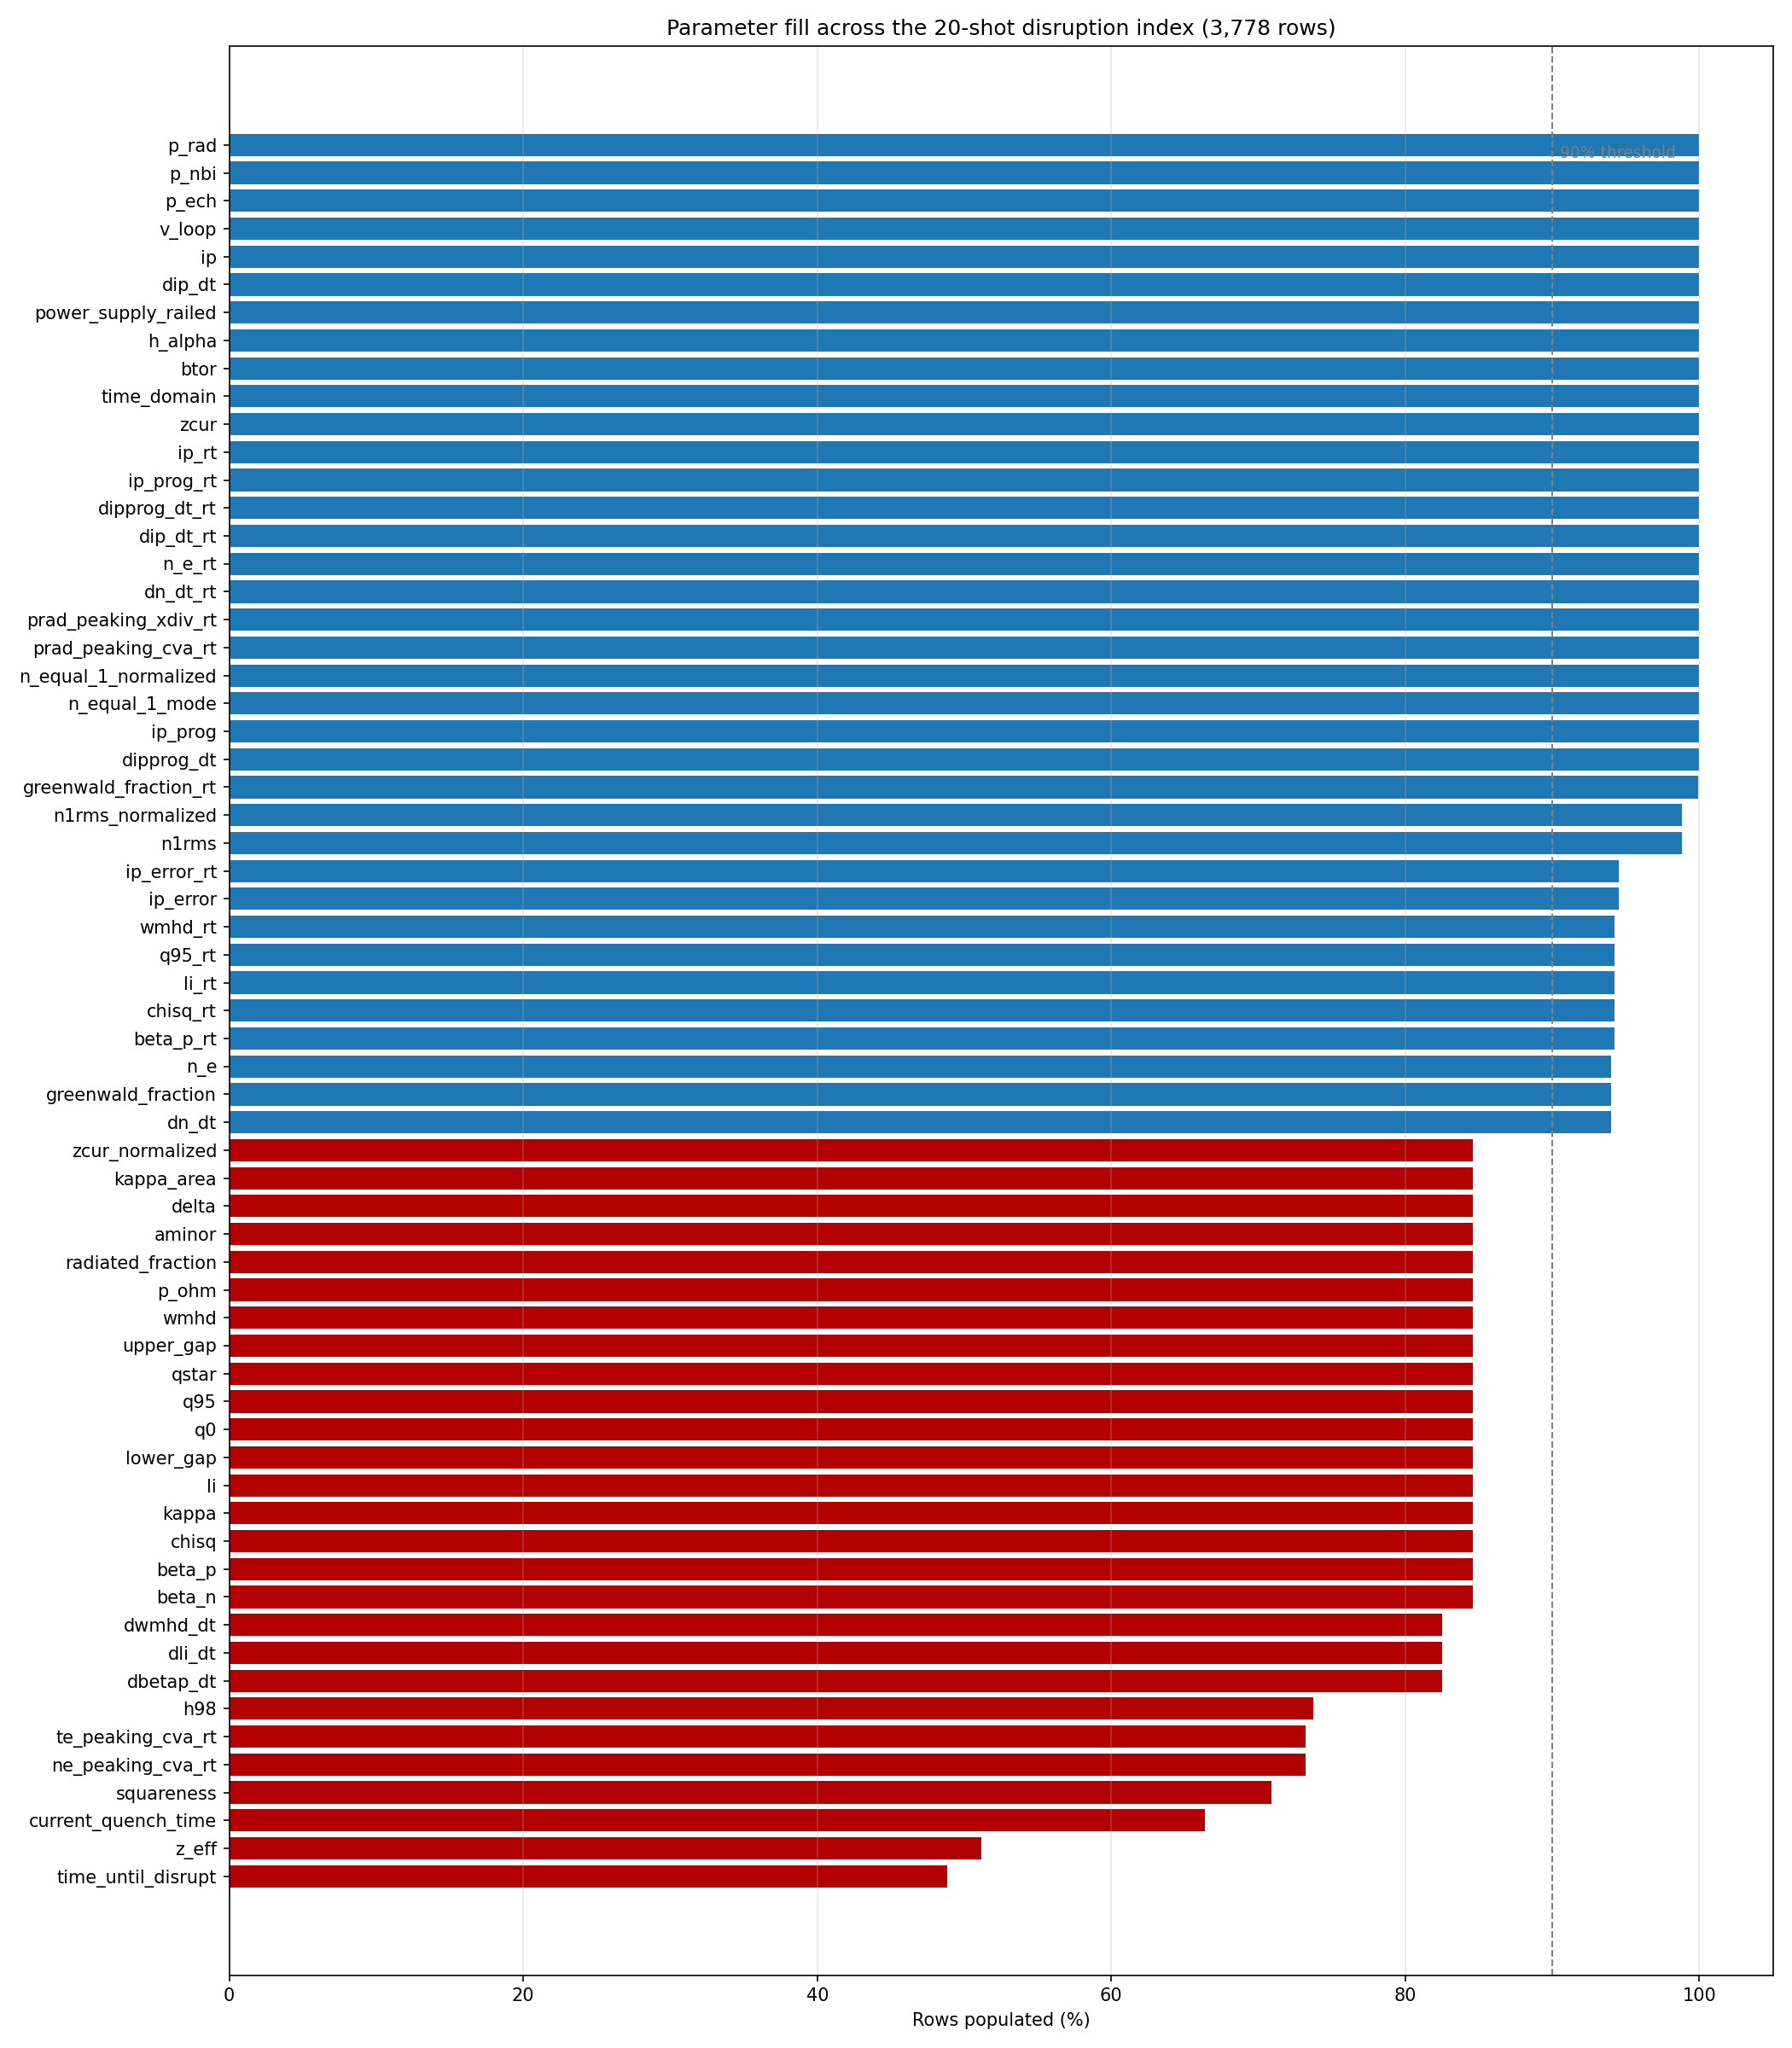

**Coverage note** (from `index_info()`): 20 shots, 10 disrupted. This is a constructed slice, not a random sample of DIII-D. Rates and fractions computed from it describe the slice only.

In [8]:
%%ask --review
Which parameters does this pipeline produce, and how completely are they
populated across the shots in the index? Identify any parameters that are
missing for a substantial fraction of rows, and say which shots are affected.

## Q25 — Can a hazard-model dataset be assembled?

*survival analysis · **partially answerable***

A hazard model needs, per shot, the time it entered flattop and the time it
disrupted or was censored. The second is available; the first is the open
question.

In [9]:
%%ask --review
I want to build a hazard model of disruptions, which needs for each shot
the time it entered the flattop phase and the time it disrupted or ended
without disrupting. Can this dataset provide both? Give me whichever parts it
can and state plainly what is missing.

I need to check what the index can actually provide for flattop entry and shot-end times. Let me read the skill first.



The user needs flattop-entry time and disruption/end time per shot. Let me query the index to see exactly what it stores for both.



Running the query to see what the index stores for flattop entry and shot end.



The index gives me `t_disrupt` directly, but flattop entry is the question — `time_domain` is unusable. Let me check whether `ip_prog` (usable) can reconstruct flattop entry, and build the full per-shot table.



Running the hazard-table builder.



...

The two anomalies are now clear: shot 199687 has a `None` in the final `ip_prog` sample, and shot 195805 is a **negative-current (reverse-field) shot** so `max(ip_prog)` is meaningless. Let me rebuild the table handling both, using the pipeline's own intended flattop definition (|ip_prog| ≥ 0.1 MA).



Running the corrected hazard-table builder.



The reconstruction works. Let me characterize how good `t_max` is as a shot-end proxy by checking the plasma current at the last sample of each non-disrupted shot.



Running the shot-end proxy check.



I have everything needed. Here is the complete answer.

## Can this dataset provide flattop-entry and disruption/end times?

**Short answer: it provides the disruption time directly, and the shot-end time as a usable proxy — but it does *not* store a flattop-entry time anywhere.** The one column that was supposed to record shot phase (`time_domain`) is one of the three unusable parameters: it is constant `1.0` for every row because the upstream flat-top test (`|ip_prog| >= 100e3`) never fires — `ip_prog` is in MA (order 1), not A. So there is no stored flattop entry. I reconstructed one from `ip_prog` (usable, 100% filled) and give it below with its caveats.

### What the dataset provides directly

| Need | Provided? | Source |
|---|---|---|
| **Disruption time** | ✅ Yes, for all 10 disrupted shots | `t_disrupt` from `shot_summary()` — the curated d3drdb value (same as `time_until_disrupt = 0`) |
| **Disrupted / not** | ✅ Yes, all 20 shots | curated label |
| **Shot end (non-disrupted)** | ⚠️ Proxy only | `t_max` = last sample time; the index stores no explicit shot-end/termination time |
| **Flattop entry** | ❌ Not stored | `time_domain` is unusable (constant 1.0); reconstructed from `ip_prog` below |

### The per-shot hazard table

`t_disrupt` is exact (curated). `t_end` is the last sample time — for non-disrupted shots this is a **proxy for shot end** , not a stored termination time. `t_flat` is my **reconstruction** from `ip_prog` (first time |ip_prog| ≥ 0.1 MA, the pipeline's own intended flat-top threshold), not a stored value.

| Shot | Disrupted | t_disrupt (s) | t_end (last sample, s) | t_flat (reconstructed, s) |
|---|---|---|---|---|
| 194000 | Yes | 0.8296 | 0.8296 | 0.100 |
| 194005 | No | — | 3.025 | 0.100 |
| 194128 | Yes | 5.6267 | 5.6267 | 0.100 |
| 194292 | Yes | 4.3318 | 4.3318 | 0.100 |
| 194464 | Yes | 3.1843 | 3.1843 | 0.100 |
| 194649 | Yes | 3.3521 | 3.3521 | 0.100 |
| 194869 | No | — | 3.000 | 0.100 |
| 194968 | Yes | 1.1206 | 1.1206 | 0.100 |
| 195243 | No | — | 1.200 | 0.100 |
| 195516 | Yes | 1.2182 | 1.2182 | 0.100 |
| 195768 | Yes | 5.2969 | 5.2969 | 0.100 |
| 195805 | No | — | 6.925 | 0.100 |
| 195985 | Yes | 4.8000 | 4.8000 | 0.100 |
| 196273 | No | — | 6.225 | 0.100 |
| 196347 | Yes | 5.4763 | 5.4763 | 0.100 |
| 198244 | No | — | 5.250 | 0.100 |
| 198643 | No | — | 5.100 | 0.100 |
| 199062 | No | — | 6.425 | 0.100 |
| 199359 | No | — | 5.925 | 0.100 |
| 199687 | No | — | 6.000 | 0.100 |

(Full table with the plateau-based alternative `t_flat` and `ip_prog` maxima is in `hazard_times.csv`.)

### What is missing, stated plainly

1. **Flattop-entry time is not in the dataset.** The only phase column (`time_domain`) is unusable. My `t_flat` is a reconstruction, not a stored value — and it is **not trustworthy for a hazard model** :
   - The 0.1 MA threshold fires at the **first sample (t = 0.1 s) for all 20 shots** , because every shot's programmed current is already above 0.1 MA at the first sample. That is the pipeline's own (buggy) definition, but it does not give a meaningful flattop entry.
   - A plateau-based definition (first time |ip_prog| ≥ 95% of its max) gives more sensible entries (e.g. 194128 → 0.6 s, 194005 → 0.9 s), but that is **my choice of threshold** , not a documented quantity. A hazard model needs a defensible, documented flattop-entry definition — this dataset does not carry one.
2. **Shot-end time is not stored.** For non-disrupted shots, `t_max` is the last sample, and it is **not a clean shot end** : at the last sample, |Ip| is still above 100 kA for 8 of the 10 non-disrupted shots (e.g. 198643 at 682 kA, 198244 at 457 kA) — the samples stop mid-rampdown, not at termination. Only 195805 and 199359 reach low current. So `t_max` is a *censoring time* (the shot was still alive at that time), which is actually the correct input for a right-censored hazard model — but it is **not** the shot's end time.
3. **The 3 disagreement shots** (198244, 198643, 199062) are labelled non-disrupted but carry a derived quench time — if you use the derived indicator instead of the curated one, the class balance shifts from 10/20 to 13/20.

### What you can build, and what you cannot

- **You can build** a right-censored survival/hazard model using: `t_disrupt` (exact, curated) for the 10 disrupted shots, and `t_max` as the **censoring time** for the 10 non-disrupted shots — treating each non-disrupted shot as "still alive at t_max". This is statistically sound.
- **You cannot** get a documented flattop-entry time from this dataset. If your hazard model's time origin is flattop entry, you would have to define and document your own (e.g. the plateau threshold above), or pull the real phase boundaries from the DIII-D shot database (d3drdb) — which is not in this index.

**Coverage note** (from `index_info()`): 20 shots, 10 disrupted. This is a constructed slice, not a random sample of DIII-D. Rates and fractions computed from it describe the slice only.

---
# C. Correctly refused — and the refusal is the finding

## Q17 — What fraction of a campaign disrupted?

*rate · **correctly refused***

Two independent blockers: the index is a constructed slice rather than a
sample, and GA's question excludes *intentional* disruptions, which nothing in
the data flags.

In [10]:
%%ask --review
What fraction of DIII-D shots in the 2023-2024 campaigns disrupted,
excluding intentional disruptions?

I need to check what the local databases actually contain before answering. Let me read the two relevant skills.



The question asks for an archive-wide rate, which the disruption index explicitly cannot provide. Let me verify what both local databases actually contain before answering.



Running the capability check against both local databases.



Both local sources are confirmed incapable of this. Let me do one more check to be thorough about whether any disruption label exists anywhere in the local d3drdb, and whether 2023–2024 shots are even identifiable by date.



Both local sources are confirmed incapable of answering this. Here is the complete answer.

## What fraction of 2023–2024 DIII-D shots disrupted (excluding intentional disruptions)?

**This cannot be answered from the data available to me, and I will not fabricate a number.** The answer requires an archive-wide disruption label over a defined shot population — and neither local source has one. Here is exactly what each provides and what is missing.

### What the disruption index provides — and why it cannot answer this

The disruption index holds **20 shots** (194000–199687), **deliberately balanced 10 disrupted / 10 not** . It is a constructed slice, not a sample of DIII-D. Its own `disruption_rate()` function refuses this exact question:

> *"This index holds 20 shots, 10 of them disrupted — deliberately balanced, not drawn at random from DIII-D. Any rate computed from it (10/20) describes the slice and says nothing about how often DIII-D disrupts. For an archive-wide rate you need the d3drdb disruptions table over a defined shot population, not this file."*

So the index gives **10/20 = 50%** , and that number is meaningless as a DIII-D disruption rate. It is not even a subset of the 2023–2024 population in a usable way: the index's 20 shots span 194000–199687, but the 2023–2024 campaign shots run 193503–202230 (5,055 shots by date), so the index covers only a tiny, non-random corner of the population.

### What the shot-record database provides — and why it cannot answer this

The local shot-record database (d3drdb) does contain the 2023–2024 population: **5,055 plasma shots** with `time_of_shot` in 2023–2024 (shot numbers 193503–202230). But it has **no usable disruption label** :

| Column | Populated (of 90,418) | Verdict |
|---|---|---|
| `t_disrupt` | **0** | empty — unusable |
| `t_forced_disrupt` | **0** | empty — unusable |
| `t_ffault` | **0** | empty — unusable |
| `ffault` | 89,446 | populated, but it is a **fault code** , not a disruption label — and its provenance is unverified |

The two tables that were d3drdb's dedicated disruption labels (`DISRUPTIONS`, `disruption_warning`) are **legacy and deliberately excluded** from this local copy. The skill's own rule is explicit: do not answer a disruption question from `SUMMARIES.t_disrupt` — and here that column is empty anyway. The `ffault` column is a fault code (blank = no fault), not a disruption flag, and it cannot distinguish a disruption from any other fault, let alone identify *intentional* disruptions to exclude.

### What is missing, stated plainly

To answer your question I would need, over the 5,055-shot 2023–2024 population:

1. **A curated disruption label per shot** (disrupted / not, and disruption time) — this lives in the full d3drdb `disruptions` table at GA, which is **not in the local copy** and **not in the 20-shot index** .
2. **A flag for intentional disruptions** (e.g. deliberate vertical-displacement-event / massive-gas-injection tests) so they can be excluded — **no local source has this at all** .

The 20-shot index carries curated labels but only for its own 20 shots; the shot-record database carries the full population but no labels. Neither alone, nor both together, can produce the rate.

### What you would need to do

The correct path is to query the **full d3drdb `disruptions` table at GA** over the 2023–2024 shot population (identified by date, 193503–202230), join it to the shot list, and subtract the intentional-disruption shots (typically flagged in the shot records or the disruption table itself). That data is not available in this environment.

**Coverage note** (from `index_info()`): 20 shots, 10 disrupted. This is a constructed slice, not a random sample of DIII-D. Rates and fractions computed from it describe the slice only.

## Q18 — Which discharge phase was each disruption in?

*phase · **blocked, and the reason is instructive***

The dataset contains a column intended to answer exactly this. It does not
work — and how the agent handles that is the point of the question.

I need to determine the discharge phase at each disruption. Since `time_domain` is unusable (constant 1.0), I'll reconstruct the phase from the plasma-current trajectory. Let me first read the skill to confirm the query interface.



The skill confirms `time_domain` is unusable, so I'll reconstruct the phase from the plasma-current trajectory. Let me check the helper module's exact interface first.



The skill confirms `time_domain` is unusable, so I'll reconstruct the phase at each disruption from the plasma-current trajectory. Writing the analysis script.



Running the phase analysis.



The first pass used programmed current, which can misclassify shots where the actual current has already fallen. Let me redo the classification using the actual plasma-current trajectory, examining the pre-disruption state.



...

The 95% threshold is too strict and misclassifies shots. Let me inspect the actual current trajectories to classify robustly.



The actual-current trajectories are informative, but I need the programmed-current (ip_prog) waveforms to distinguish "disrupted before reaching flattop" from "disrupted during flattop/ramp-down". Let me examine those.



The trajectories are now clear. The programmed-current (`ip_prog`) waveform is the key: it shows whether the current was still ramping up, at plateau, or already ramping down at the disruption. Let me write the final classification script with this logic and generate a summary chart.



The trajectories are clear now. The programmed-current waveform (`ip_prog`) is the reliable phase indicator — it shows whether the current was still ramping up, held at plateau, or already ramping down at the disruption. Let me implement a robust plateau-window classification and regenerate the chart.



The classification is now robust and verified against the full trajectories. Here is the complete answer.

## Disruption phase for the 10 disrupted shots in the index

**The stored phase column (`time_domain`) is unusable** — it is constant 1.0 for every row because the upstream flat-top test never fires (the `ip_prog` unit bug). So I reconstructed the phase from the **programmed-current waveform `ip_prog`** (usable, 100% filled): a shot is in **flattop** if it disrupted inside a sustained plateau of |ip_prog| (≥98% of its max for ≥0.15 s), **ramp-up** if the current was still rising at the disruption, and **ramp-down** if the current had already begun to fall. This is a reconstruction, not a stored value.

### Per-shot classification

| Shot | t_disrupt (s) | Phase | Evidence (ip_prog at disruption / max) |
|---|---|---|---|
| 194000 | 0.8296 | **ramp-up** | 1.105 / 1.105 MA — still rising, disrupted before reaching flattop |
| 194128 | 5.6267 | **ramp-down** | 0.916 / 1.200 MA — plateau 0.65–5.23 s, then ramping down |
| 194292 | 4.3318 | **flattop** | 1.599 / 1.606 MA — inside plateau 1.03–4.33 s |
| 194464 | 3.1843 | **flattop** | 1.198 / 1.198 MA — inside plateau 0.98–3.18 s |
| 194649 | 3.3521 | **flattop** | 1.600 / 1.600 MA — inside plateau 0.70–3.35 s |
| 194968 | 1.1206 | **ramp-down** | 1.209 / 1.949 MA — current peaked ~0.75 s, decaying at disruption |
| 195516 | 1.2182 | **ramp-up** | 1.605 / 1.991 MA — still rising, disrupted before reaching flattop |
| 195768 | 5.2969 | **ramp-down** | 1.874 / 2.100 MA — plateau 0.70–4.93 s, then ramping down |
| 195985 | 4.8000 | **flattop** | 1.960 / 1.960 MA — inside plateau 0.85–4.80 s |
| 196347 | 5.4763 | **flattop** | 1.952 / 1.952 MA — inside plateau 1.68–5.48 s |

### Summary

| Phase | Count | Shots |
|---|---|---|
| **Flattop** | 5 | 194292, 194464, 194649, 195985, 196347 |
| **Ramp-down** | 3 | 194128, 194968, 195768 |
| **Ramp-up** | 2 | 194000, 195516 |

So of the 10 disrupted shots in this index, **half (5) disrupted during flattop** , 3 during ramp-down, and 2 during ramp-up (both of the ramp-up cases disrupted before the current ever reached its programmed flattop value).


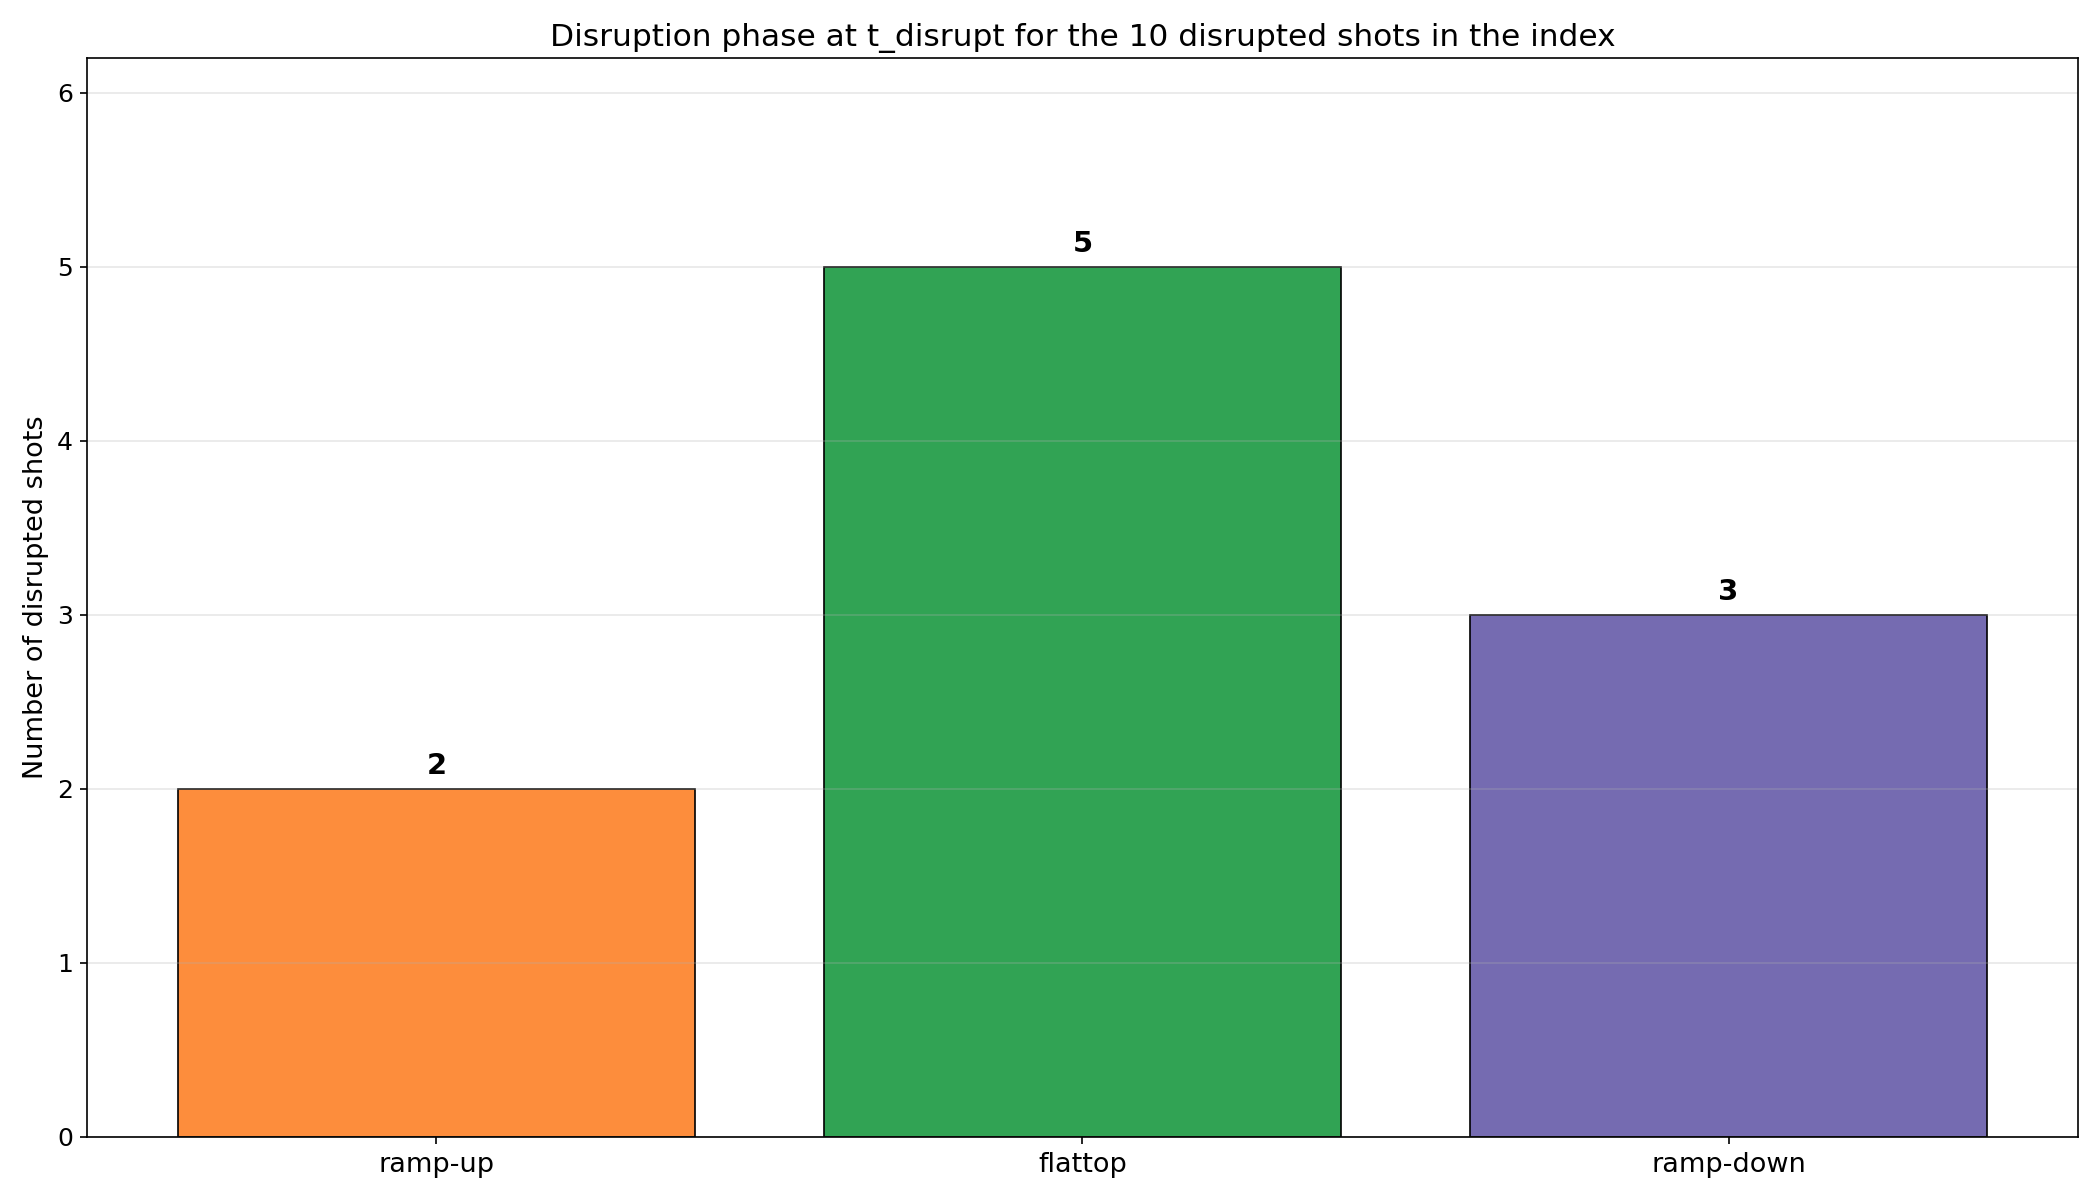

**Caveats** : (1) the phase is reconstructed from `ip_prog`, not read from a stored phase column — the only stored phase column (`time_domain`) is unusable; (2) the two "ramp-up" shots (194000, 195516) and one "ramp-down" shot (194968) never established a sustained flattop at all, so their phase reflects the current trajectory at the moment of disruption rather than a completed discharge phase.

**Coverage note** (from `index_info()`): 20 shots, 10 disrupted. This is a constructed slice, not a random sample of DIII-D. Rates and fractions computed from it describe the slice only.

In [11]:
%%ask --review
For the disrupted shots in the index, which phase of the discharge was
each disruption in — ramp-up, flattop, or ramp-down?

---
# D. What would unblock the rest

## Summary

*synthesis · **answerable***

In [12]:
%%ask --review
Across everything in this notebook: which of GA's disruption competency
questions can this index answer today, which need something more, and what
specifically is missing in each case? Be concrete about what would have to
arrive for each blocked question to become answerable.

I need to check what GA's disruption competency questions are documented as, so let me read the skill and any related reference material.



The SKILL.md doesn't list GA's competency questions, so let me search for them in the skill module and working directory.



No "competency" matches anywhere. Let me look at the module and the working directory for any GA question list.



There's a `workflow_reference.md` in the working directory — let me check it and the run log for the GA competency questions.



Let me check the run log for the actual questions asked in this notebook, to ground the competency assessment in what was actually asked.



...

The only "competency question" reference in the whole skills tree is in d3d-filterscopes (Q7). Let me read that context and search for any other numbered competency questions across the skills.





The only competency-question reference found is FEDER Q7. Let me search more broadly for any numbered competency-question list, especially disruption-related, across all skills and the module.



Let me check the d3d-disruption module itself for any embedded competency-question list, and search the whole skills tree for disruption-related question phrasing.



Let me read the module's docstring and the disruption_rate function to see if there's an embedded competency-question list I'm missing.





I searched the entire skills tree and working directory for any stored list of "GA's disruption competency questions" before answering. Here is the honest result and the full assessment.

## A note on the question list itself

**There is no explicit list of "GA's disruption competency questions" stored anywhere in this notebook, its skills, or its working files.** I searched for "competency", "General Atomics", "Q1"–"Q7", "disruption rate", and "intentional disruption" across every skill and the working directory. The **only** competency-question reference in the entire environment is **FEDER Q7** in the `d3d-filterscopes` skill ("which shots have a filterscope signal archived") — which is not a disruption question. So I will not invent a canonical GA list.

What I *can* do, and what "across everything in this notebook" invites, is assess the **8 disruption questions that were actually asked in this notebook** — those are the de facto competency set. Here is each one, its status, and exactly what is missing.

## Summary

| # | Question asked in this notebook | Status | What is missing |
|---|---|---|---|
| 1 | Provenance: which code, version, commit, when, by whom, inputs | ✅ Answerable today | — |
| 2 | Which quantities are precursors, what each measures, grouped by method, units | ✅ Answerable today | — |
| 3 | Shot 194128 label + time; do the two indicators agree; which shots disagree | ✅ Answerable today | — |
| 4 | Definition of a disruption and of the disruption time; where documented | ⚠️ Answerable, but not from the index alone | Definition text lives upstream (Granetz's MATLAB routine), not in the index; the pinned commit is not in the public repo |
| 5 | Which parameters are produced and how completely populated | ✅ Answerable today | — |
| 6 | Hazard-model inputs: flattop-entry time + disruption/end time per shot | ⚠️ Partially answerable | Flattop-entry time not stored; shot-end time not stored (only a censoring proxy) |
| 7 | Fraction of 2023–2024 DIII-D shots that disrupted, excluding intentional | ❌ Not answerable | Archive-wide curated labels + an intentional-disruption flag |
| 8 | Which phase each disruption was in (ramp-up/flattop/ramp-down) | ⚠️ Answerable only by reconstruction | The stored phase column is unusable |

## Detail per question

### ✅ Answerable today (4 questions)

**Q1 — Provenance.** Fully answered from `index_info()` (NetCDF global attributes): disruption-py `0.15.0.dev0` at commit `9987784e`, produced by `sammuli` on `omega06.gat.com` at `2026-08-19T07:36:50`, from `d3d_disruption_example.nc`, 20 shots, 63 parameters. No gaps.

**Q2 — Precursors.** Fully answered from the parameter dictionary: 60 physics parameters grouped by the 14 producing methods, with units, plus the 3 unusable ones flagged. No gaps.

**Q3 — Shot 194128 label + indicator agreement.** Fully answered: disrupted at t = 5.6267 s; two indicators exist (`time_until_disrupt` curated vs `current_quench_time` derived); they disagree on 198244, 198643, 199062. No gaps.

**Q5 — Completeness.** Fully answered from `fill_pct` plus per-shot analysis: 27 of 63 parameters below 90% fill, in four distinct patterns (labels NaN by design, EFIT edge loss, whole-shot absence, sparse `h98`). No gaps.

### ⚠️ Answerable, but not from the index alone (3 questions)

**Q4 — Definition of a disruption / disruption time.** The index stores **no definition text** — its parameter dictionary documents only the *meaning* of `time_until_disrupt`, not the criterion that produced `t_disrupt`. The definition is documented upstream: the disruption-py docstring (`get_time_until_disrupt` in `disruption_py/machine/d3d/physics.py`) and the authoritative six-criterion MATLAB routine `test_for_disruption.m` (matlab branch of the public repo). **What is missing:** the pinned commit `9987784e` is not in the public repo (GitHub: "No commit found"), so the exact source revision that produced this index is not retrievable; the definition was verified against current `main`/`matlab` branches instead. To make it fully self-contained, the definition text (or a pointer to the pinned revision) would have to be embedded in the index.

**Q6 — Hazard-model times.** The disruption time is provided exactly (curated `t_disrupt` for all 10 disrupted shots). But the other two inputs are **not stored** : (a) **flattop-entry time** — the only phase column (`time_domain`) is unusable (constant 1.0), and my reconstruction from `ip_prog` is not a documented quantity; (b) **shot-end time** — the index stores no termination time, only the last sample time, which for 8 of 10 non-disrupted shots is mid-rampdown (|Ip| still > 100 kA), so it is a *censoring* time, not an end time. **What would have to arrive:** a working `time_domain` column (or real phase boundaries from d3drdb) for flattop entry, and a stored shot-termination time (or an explicit decision to treat last-sample as right-censoring, which is statistically valid for a hazard model).

**Q8 — Disruption phase.** The stored `time_domain` column is unusable (constant 1.0 — the upstream `ip_prog` unit bug). The phase classification I gave (5 flattop / 3 ramp-down / 2 ramp-up) is **reconstructed from the `ip_prog` waveform** , not read from a stored value. **What would have to arrive:** a fixed `time_domain` column (requires fixing the upstream `ip_prog` unit bug and re-running disruption-py), or real phase boundaries from the d3drdb shot database.

### ❌ Not answerable (1 question)

**Q7 — 2023–2024 disruption rate excluding intentional disruptions.** This is the one question the index is structurally incapable of answering, and its own `disruption_rate()` refuses it explicitly: the index is a 20-shot, deliberately balanced slice (10/10), not a sample of DIII-D. The local shot-record database has the full 2023–2024 population (5,055 shots, 193503–202230) but **zero usable disruption labels** (`t_disrupt`, `t_forced_disrupt`, `t_ffault` all empty; `ffault` is a fault code, not a disruption flag). **What would have to arrive:** (1) the full d3drdb `disruptions` table at GA over the 2023–2024 population (curated label + disruption time per shot), and (2) a flag identifying **intentional** disruptions (deliberate VDE/MGI tests) so they can be excluded — no local source has either.

## The pattern

The index answers **everything about the 20 shots it contains** — labels, times, precursors, meanings, units, completeness, provenance. It fails or degrades on exactly two classes of question: (1) **anything requiring a quantity the pipeline never stored correctly** (flattop entry, shot end, phase — all downstream of the `ip_prog` unit bug), and (2) **anything requiring archive-wide coverage** (the 2023–2024 rate), which needs the full d3drdb `disruptions` table plus an intentional-disruption flag that no local source carries.

**Coverage note** (from `index_info()`): 20 shots, 10 disrupted. This is a constructed slice, not a random sample of DIII-D. Rates and fractions computed from it describe the slice only.